In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:

def plot_time_series(csv_path, max_cols_per_fig=6):
    # Load data
    df = pd.read_csv(csv_path)

    # Ensure time column exists
    if "t" not in df.columns:
        raise ValueError("CSV must contain a 't' column for time.")

    t = df["t"]
    variables = [col for col in df.columns if col != "t"]

    # --- Option 1: Single plot (all variables) ---
    plt.figure(figsize=(10, 6), dpi=1200)
    for col in variables:
        plt.plot(t, df[col], label=col)

    plt.xlabel("Time (t)")
    plt.ylabel("Value")
    plt.title("All Variables vs Time")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

    # --- Option 2: Split into multiple figures (cleaner if many variables) ---
    for i in range(0, len(variables), max_cols_per_fig):
        subset = variables[i:i + max_cols_per_fig]

        plt.figure(figsize=(10, 6))
        for col in subset:
            plt.plot(t, df[col], label=col)

        plt.xlabel("Time (t)")
        plt.ylabel("Value")
        plt.title(f"Variables {i+1}–{i+len(subset)}")
        plt.legend()
        plt.tight_layout()
        plt.show()

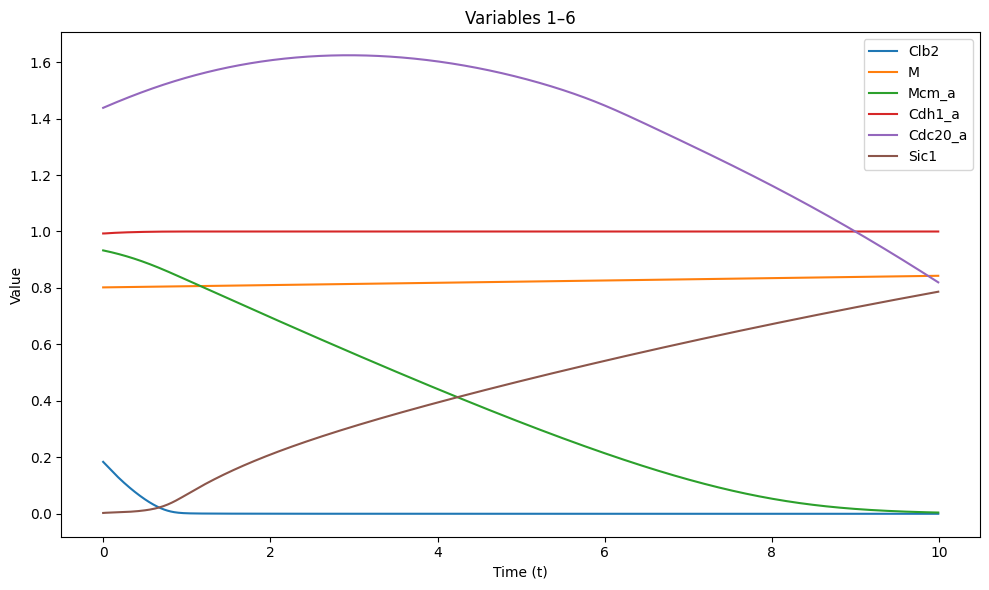

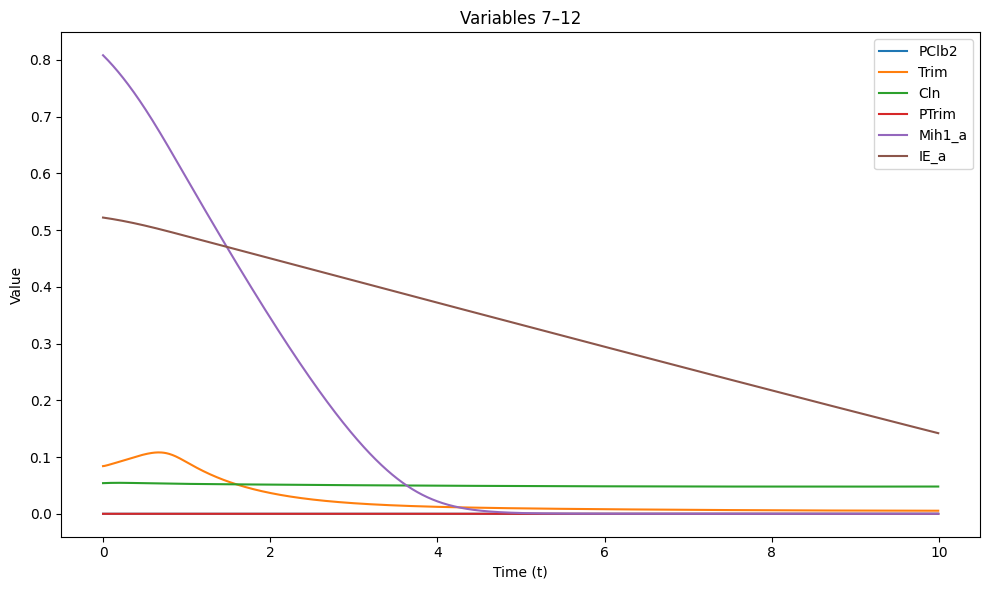

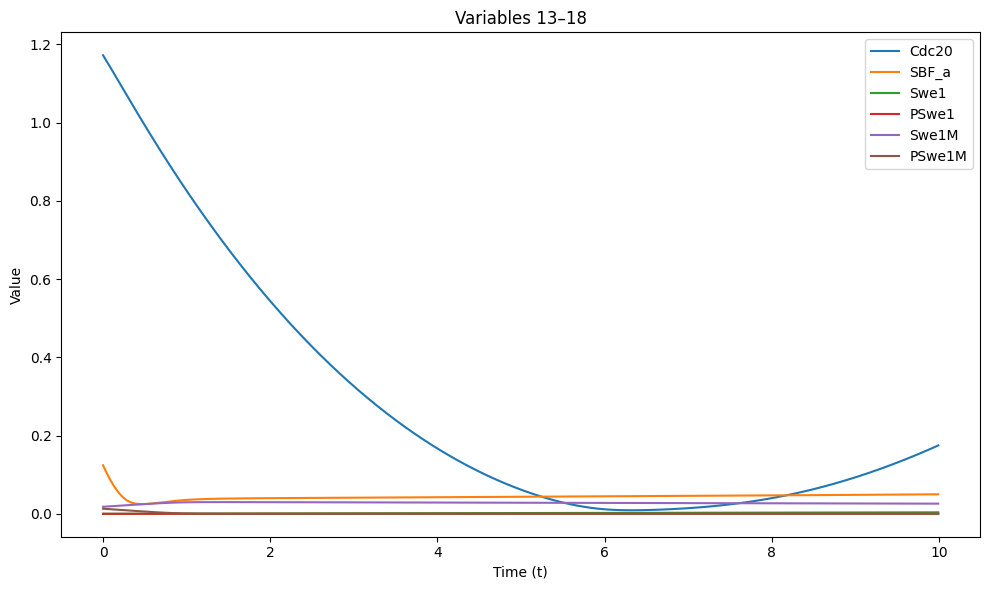

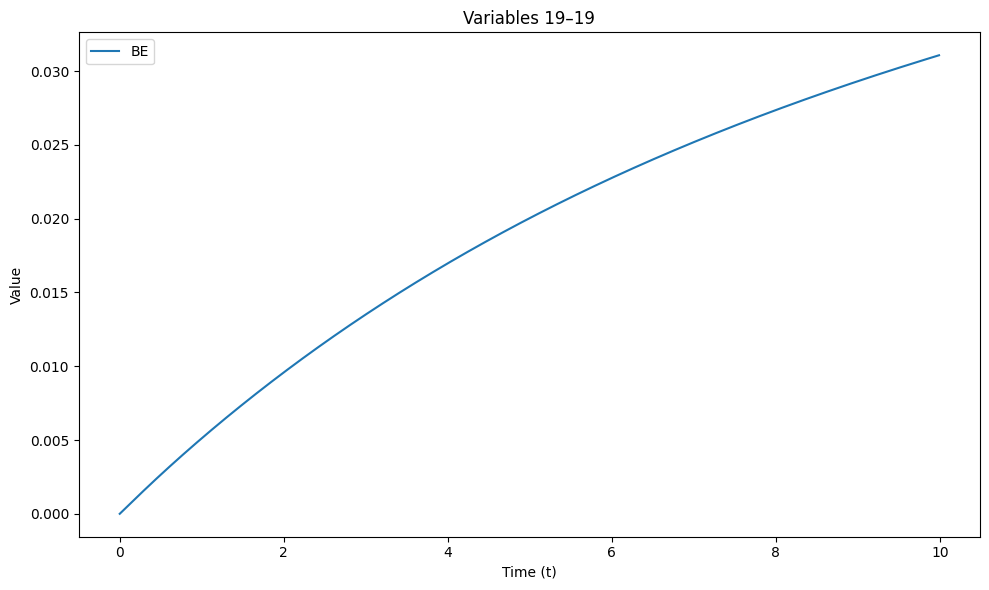

In [6]:

# ---- Usage ----
csv_file = "ciliberto_novak_tyson_2003.csv"  # <-- replace with your file path
plot_time_series(csv_file)

In [12]:
from pysr import PySRRegressor

def symbolic_regression_ode(
    csv_path,
    target_col,
    feature_cols=None,
    include_time=False,
    derivative_method="gradient",
    niterations=100,
    maxsize=20,
    populations=8,
    population_size=50,
    unary_operators=None,
    binary_operators=None,
    random_state=0,
    show_plots=True,
):
    """
    Learn an ODE of the form d(target_col)/dt = f(features)

    Parameters
    ----------
    csv_path : str
        CSV containing time series data with a 't' column.
    target_col : str
        State variable whose ODE should be learned.
    feature_cols : list[str] or None
        Input variables for the RHS. If None, uses all state columns except target_col.
    include_time : bool
        Whether to include t itself as an input feature.
    derivative_method : str
        Currently supports "gradient".
    niterations, maxsize, populations, population_size : PySR settings
    show_plots : bool
        Show derivative-fit diagnostic plots.

    Returns
    -------
    model : fitted PySRRegressor
    results_df : DataFrame with t, true derivative, predicted derivative
    """
    df = pd.read_csv(csv_path)

    if "t" not in df.columns:
        raise ValueError("CSV must contain a 't' column.")
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found.")

    # Default features: all non-time, non-target variables
    if feature_cols is None:
        feature_cols = [c for c in df.columns if c not in ("t", target_col)]

    for c in feature_cols:
        if c not in df.columns:
            raise ValueError(f"Feature column '{c}' not found.")

    needed_cols = ["t", target_col] + feature_cols
    work_df = df[needed_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()

    t = work_df["t"].to_numpy(dtype=float)
    x = work_df[target_col].to_numpy(dtype=float)

    # sort by time in case input is unordered
    order = np.argsort(t)
    work_df = work_df.iloc[order].reset_index(drop=True)
    t = work_df["t"].to_numpy(dtype=float)
    x = work_df[target_col].to_numpy(dtype=float)

    # numerical derivative
    if derivative_method == "gradient":
        dxdt = np.gradient(x, t)
    else:
        raise ValueError("Unsupported derivative_method. Use 'gradient'.")

    input_cols = []
    if include_time:
        input_cols.append("t")
    input_cols.extend(feature_cols)

    # Often you also want the state itself on the RHS
    if target_col not in input_cols:
        input_cols.append(target_col)

    # preserve order, remove duplicates
    seen = set()
    input_cols = [c for c in input_cols if not (c in seen or seen.add(c))]

    X = work_df[input_cols].to_numpy(dtype=float)
    y = dxdt

    if unary_operators is None:
        unary_operators = ["exp", "log", "sqrt"]
    if binary_operators is None:
        binary_operators = ["+", "-", "*", "/"]

    model = PySRRegressor(
        niterations=niterations,
        maxsize=maxsize,
        populations=populations,
        population_size=population_size,
        unary_operators=unary_operators,
        binary_operators=binary_operators,
        random_state=random_state,
        progress=True,
    )

    model.fit(X, y, variable_names=input_cols)
    y_pred = model.predict(X)

    print(f"\nLearned ODE for {target_col}:")
    print(f"d({target_col})/dt = {model.sympy()}")

    print("\nEquation table:")
    print(model.equations_)

    results_df = pd.DataFrame({
        "t": t,
        f"d{target_col}_dt_true": y,
        f"d{target_col}_dt_pred": y_pred,
    })

    if show_plots:
        plt.figure(figsize=(8, 4), dpi=300)
        plt.plot(t, y, label=f"True d{target_col}/dt")
        plt.plot(t, y_pred, label=f"Predicted d{target_col}/dt")
        plt.xlabel("t")
        plt.ylabel(f"d{target_col}/dt")
        plt.title(f"Derivative fit for {target_col}")
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(6, 6), dpi=300)
        plt.scatter(y, y_pred, s=15)
        mn = min(np.min(y), np.min(y_pred))
        mx = max(np.max(y), np.max(y_pred))
        plt.plot([mn, mx], [mn, mx], linestyle="--")
        plt.xlabel("True derivative")
        plt.ylabel("Predicted derivative")
        plt.title("Predicted vs true derivative")
        plt.tight_layout()
        plt.show()

    return model, results_df

/Users/jasonz/miniconda3/envs/physiome/lib/python3.13/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/jasonz/miniconda3/envs/physiome/lib/python3.13/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 5.260e+04
Progress: 174 / 1600 total iterations (10.875%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.989e-02  0.000e+00  y = -0.099864
3           2.305e-03  1.077e+00  y = Mcm_a * -0.34708
4           2.006e-03  1.392e-01  y = Mcm_a / log(Trim)
5           4.689e-05  3.756e+00  y = (Mcm_a * -0.47115) + 0.076021
7           4.357e-05  3.676e-02  y = (BE + (Mcm_a * -0.44936)) + Cln
9           3.457e-05  1.156e-01  y = ((Mcm_a + Cln) - (BE * 8.4673)) * -0.37548
12          3.447e-05  1.014e-03  y = (exp(Cln) * -0.3564) * ((Mcm_a + Cln) - (BE * 8.469))
14          3.441e-05  8.739e-04  y = ((Cln - (BE * 8.8652)) + ((Swe1M * sqrt(Mcm_a)) + Mcm_...
                                      a)) * -0.36483
15          3.188e-05  7.626e-02  y = ((Mcm_

[ Info: Final population:
[ Info: Results saved to:



Learned ODE for Cdc20:
d(Cdc20)/dt = -0.23792088*sqrt(BE) + 16.8492878710056*BE + Clb2**2 - 0.38796523*exp(-sqrt(PSwe1)/Cdc20)

Equation table:
    complexity          loss  \
0            1  1.988745e-02   
1            3  2.305181e-03   
2            4  4.989982e-04   
3            5  4.689153e-05   
4            7  3.634280e-05   
5            9  3.089352e-05   
6           11  2.646974e-05   
7           12  8.232921e-06   
8           14  4.571760e-06   
9           15  4.201099e-06   
10          16  1.432566e-06   
11          18  1.270950e-06   
12          20  9.998661e-07   
13          22  9.130329e-07   
14          24  9.092740e-07   
15          25  8.603765e-07   

                                             equation     score  \
0                                         -0.09986358  0.000000   
1                                 Mcm_a * -0.34707767  1.077465   
2                               1.3050092 - exp(IE_a)  1.530312   
3                    (Mcm_a * -0.471148) +

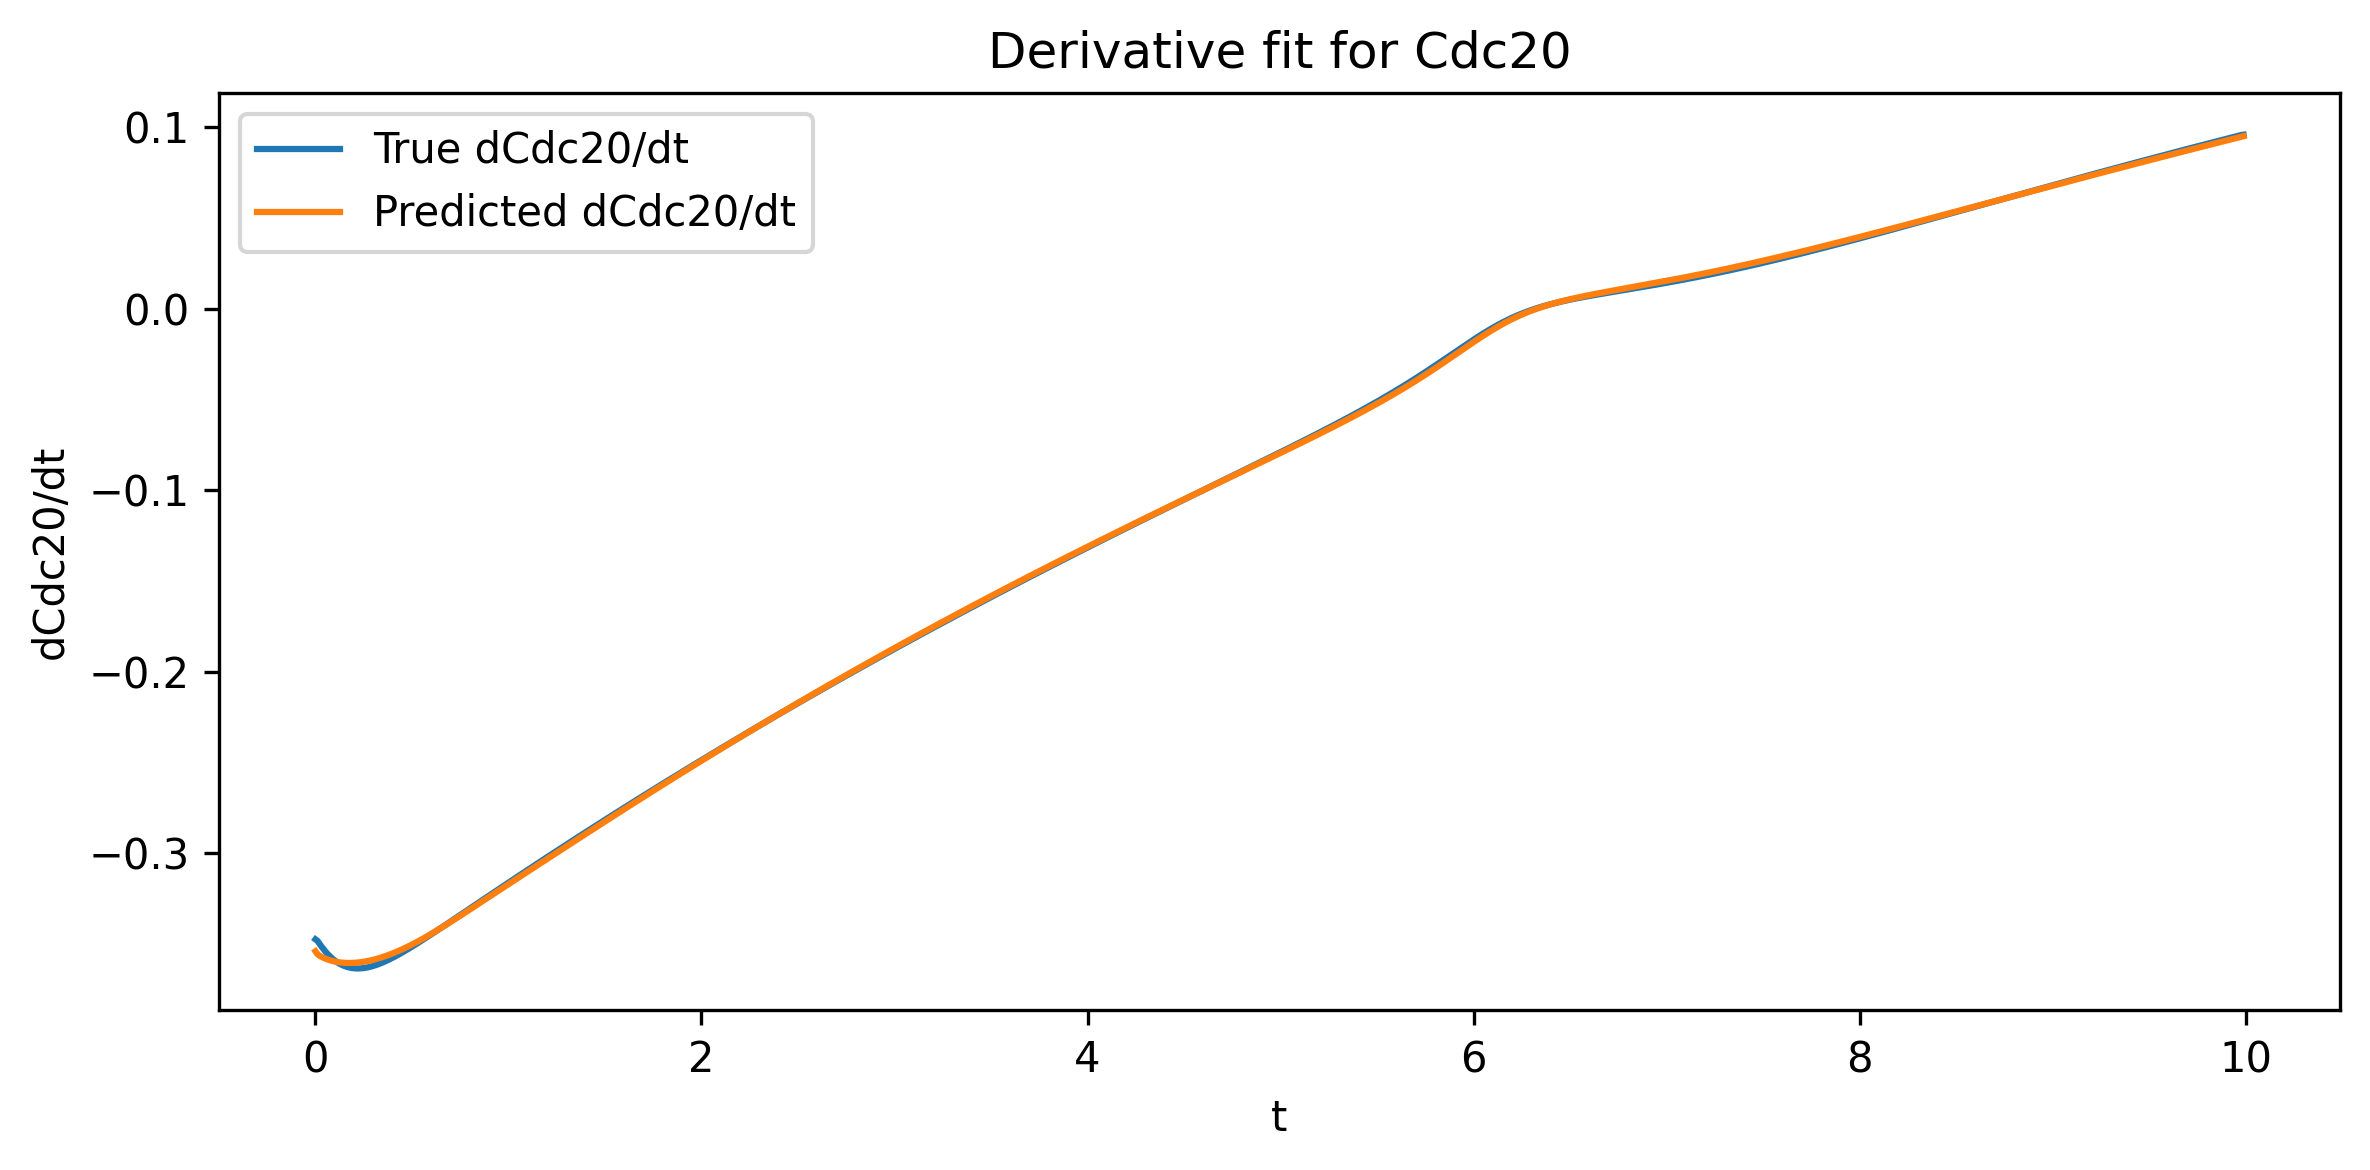

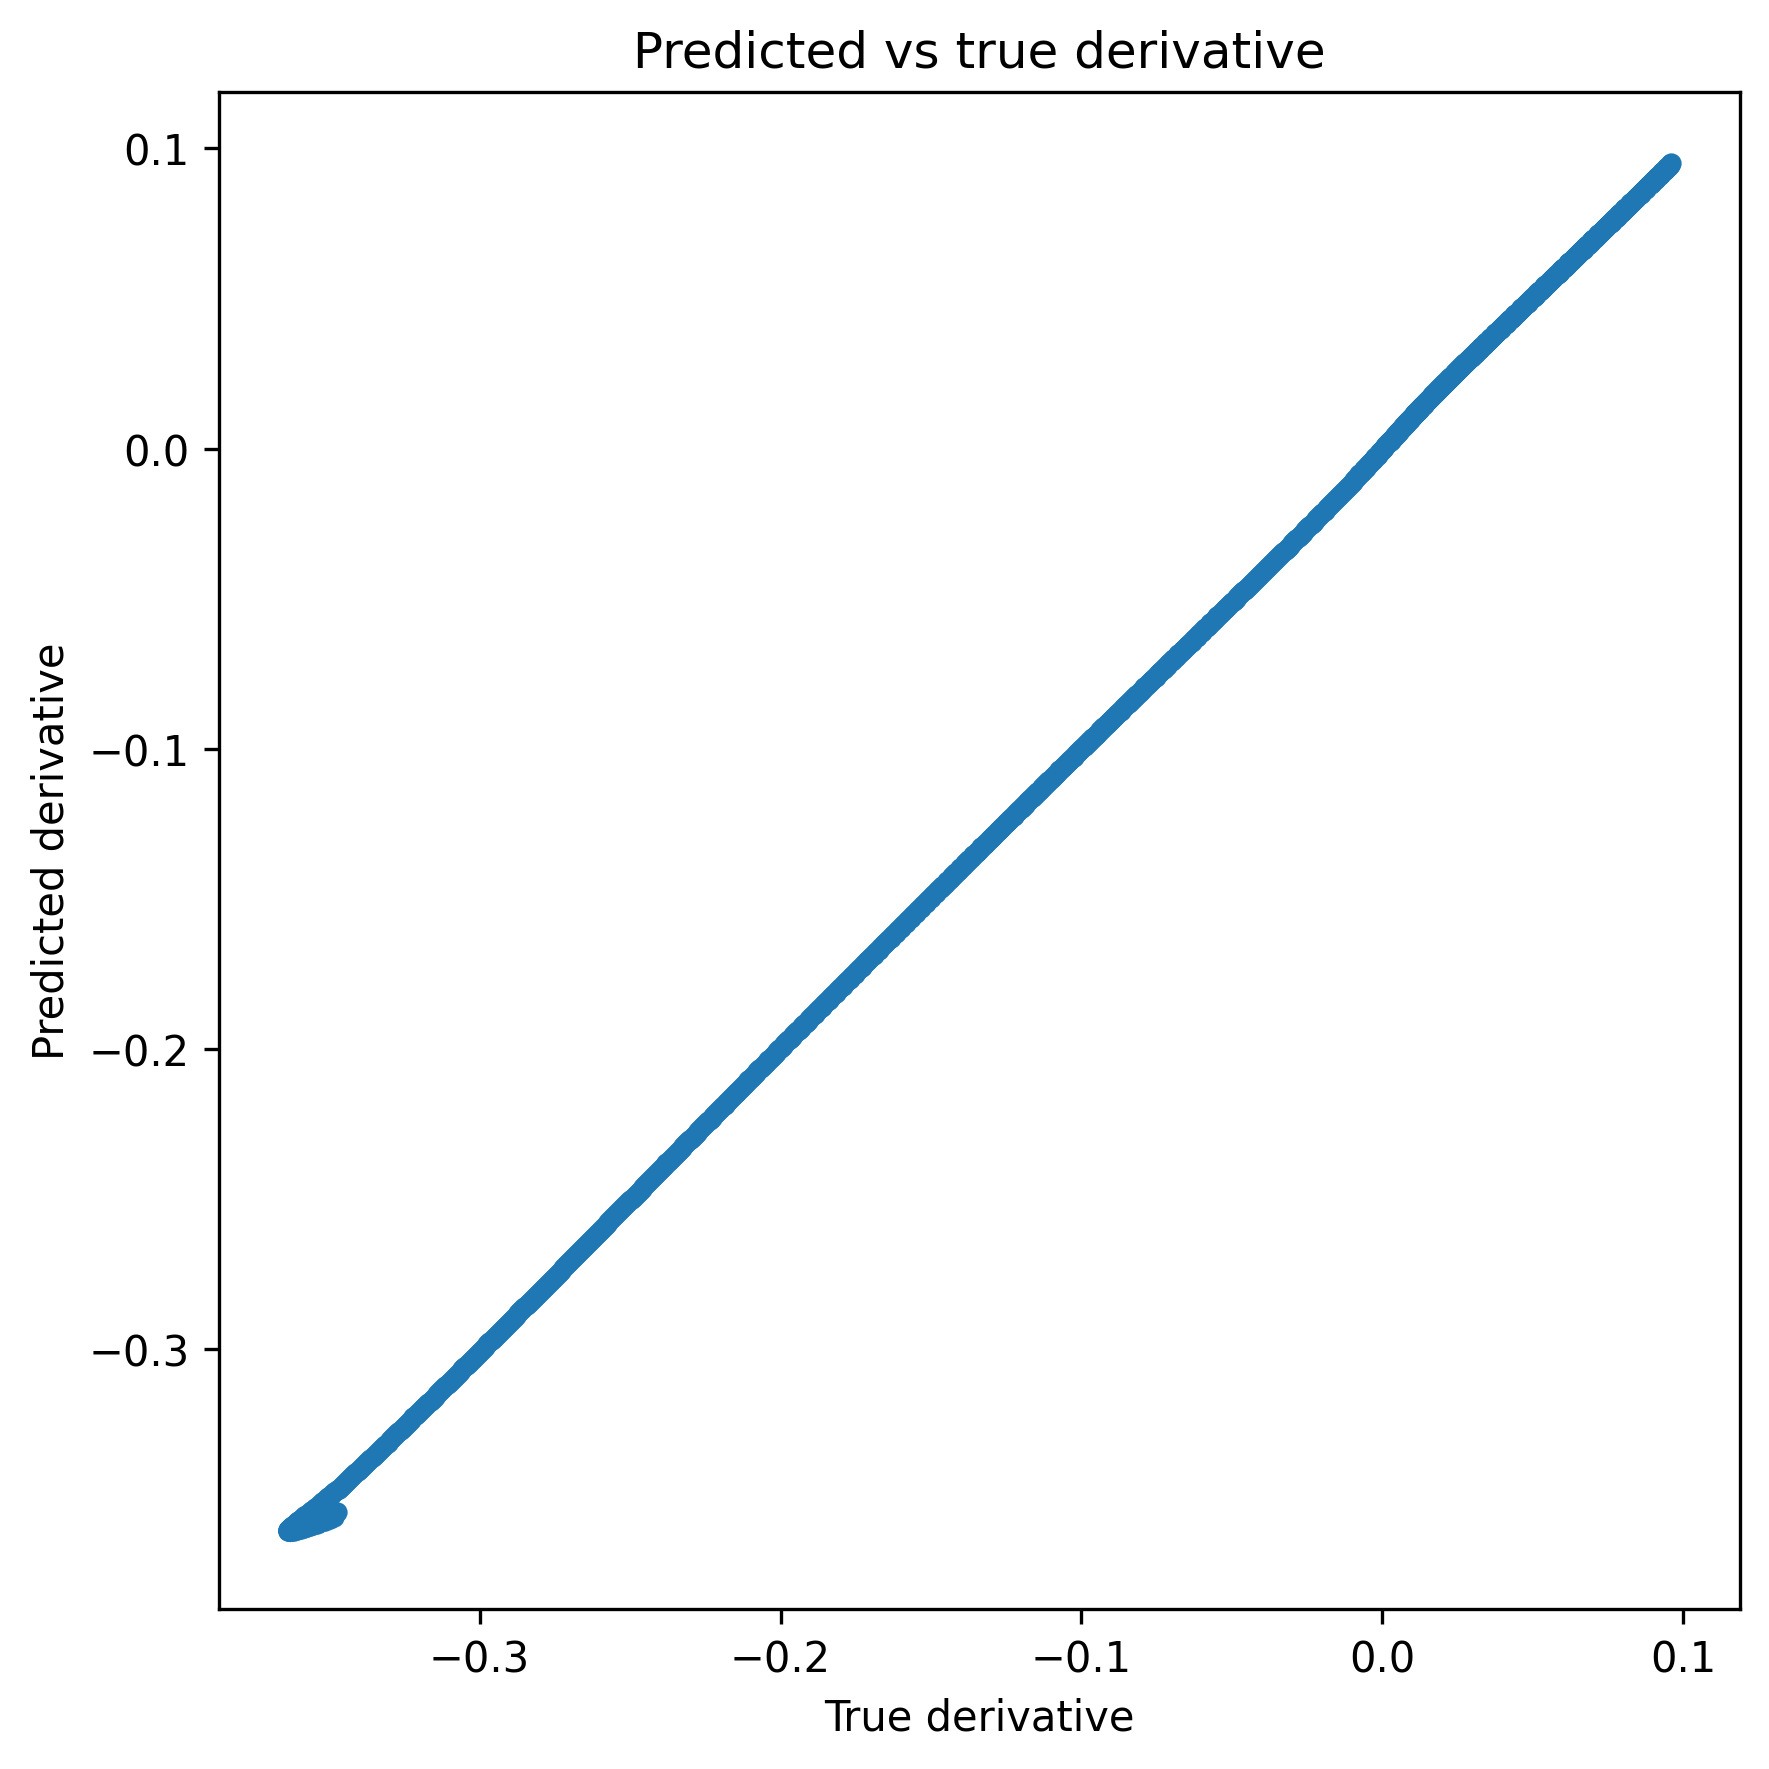

  - outputs/20260422_104613_SY5xza/hall_of_fame.csv


In [13]:
model = symbolic_regression_ode(
    csv_path=csv_file,
    target_col="Cdc20",
    feature_cols=None,   # use all remaining columns
    niterations=200,
    maxsize=25,
)